In [1]:
# === SETUP ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../plots", exist_ok=True)

# load analysis dataset ---
df = pd.read_csv("C:/Users/lalib/AppData/Local/Programs/data/analysis_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)

# merge TTF gas price (daily → hourly, forward-filled)
ttf = pd.read_csv("C:/Users/lalib/AppData/Local/Programs/data/ttf.csv")
ttf.columns = ttf.columns.str.strip().str.lower()
ttf["date"] = pd.to_datetime(ttf["date"]).dt.date
df["date"] = df["datetime"].dt.date
df = df.merge(ttf, on="date", how="left")
df["ttf_eur_mwh"] = df["ttf_eur_mwh"].ffill()

# time features in LOCAL time (SQL strftime returns UTC)
df["local"] = df["datetime"].dt.tz_convert("Europe/Athens")
df["hour"] = df["local"].dt.hour
df["month"] = df["local"].dt.month
df["day_of_week"] = df["local"].dt.dayofweek
df["year"] = df["local"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

def get_season(m):
    if m in [12, 1, 2]: return "Winter"
    elif m in [3, 4, 5]: return "Spring"
    elif m in [6, 7, 8]: return "Summer"
    else: return "Fall"

df["season"] = df["month"].apply(get_season)

# --- sort by time (essential for lag features later) ---
df = df.sort_values("datetime").reset_index(drop=True)

print("Shape:", df.shape)
print("Range:", df["local"].min(), "→", df["local"].max())

Shape: (35065, 20)
Range: 2022-08-01 00:00:00+03:00 → 2026-08-01 00:00:00+03:00


In [2]:
df=df[df["local"]<"2025-08-01"].copy()
print("Modelling window:",df["local"].min(), "→" ,df ["local"].max(), "|", len(df), "rows" )
df["residual_load"]=df["load"]-df["solar"]-df["wind"]

df["price_lag_24"]=df["price"].shift(24)
df["price_lag_168"]=df["price"].shift(168)
df["load_lag_24"]=df["load"].shift(24)


df["price_roll_24"]=df["price"].shift(1).rolling(24).mean()
df["ttf_roll_7d"]=df["ttf_eur_mwh"].shift(1).rolling(168).mean()

df["hour_sin"]=np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]=np.cos(2*np.pi*df["hour"]/24)

df["crisis"]=(df["local"]< "2023-07-01").astype(int)

print("\nMissing per feature:")
feats = ["price","load","solar","wind","gas","ttf_eur_mwh","residual_load",
         "price_lag_24","price_lag_168","price_roll_24","hour_sin","hour_cos","crisis"]

print(df[feats].isna().sum())


Modelling window: 2022-08-01 00:00:00+03:00 → 2025-07-31 23:00:00+03:00 | 26304 rows

Missing per feature:
price              0
load               3
solar              8
wind               8
gas               10
ttf_eur_mwh        3
residual_load      9
price_lag_24      24
price_lag_168    168
price_roll_24     24
hour_sin           0
hour_cos           0
crisis             0
dtype: int64


In [17]:
FEATURES = ["load", "solar", "wind", "gas", "residual_load", "ttf_eur_mwh",
            "price_lag_24", "price_lag_168", "price_roll_24", "ttf_roll_7d",
            "hour_sin", "hour_cos", "day_of_week", "month", "is_weekend", "crisis"]

model_df = df.dropna(subset=FEATURES + ["price"]).copy()

split_date = "2025-02-01"
train = model_df[model_df["local"] < split_date]
test  = model_df[model_df["local"] >= split_date]

X_train, y_train = train[FEATURES], train["price"]
X_test,  y_test  = test[FEATURES],  test["price"]

print(f"Train: {len(train)}  ({train['local'].min().date()} → {train['local'].max().date()})")
print(f"Test:  {len(test)}  ({test['local'].min().date()} → {test['local'].max().date()})")
print("NaNs:", X_train.isna().sum().sum(), X_test.isna().sum().sum())

model_df.to_csv("../data/model_dataset.csv", index=False)

Train: 21779  (2022-08-08 → 2025-01-31)
Test:  4341  (2025-02-01 → 2025-07-31)
NaNs: 0 0


In [15]:
##BASELINE



from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_pred=test["price_lag_168"]

mae_base=mean_absolute_error(test["price"], baseline_pred)
rmse_base=np.sqrt(mean_squared_error(test["price"],baseline_pred))
print(f"Baseline - MAE: €{mae_base:.2f}  RMSE: €{rmse_base:.2f}")

Baseline - MAE: €28.13  RMSE: €41.71


In [ ]:
##LINEAR REGRESSION

from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X_train, y_train)      # ← the missing line
lr_pred = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f"Linear    — MAE: €{mae_lr:.2f}  RMSE: €{rmse_lr:.2f}")

Linear    — MAE: €21.07  RMSE: €28.27


In [22]:
##LIGHTGBM

import lightgbm as lgb

lgb_model=lgb.LGBMRegressor(
    n_estimators=1000,
    learing_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train,
              eval_set=[(X_test,y_test)],
              eval_metric="l1",
              callbacks=[lgb.early_stopping(50,verbose=False)])


lgb_pred=lgb_model.predict(X_test) 

mae_lgb=mean_absolute_error(y_test,lgb_pred)
rmse_lgb = np.sqrt(mean_squared_error(y_test, lgb_pred))
print(f"LightGBM  — MAE: €{mae_lgb:.2f}  RMSE: €{rmse_lgb:.2f}")
print(f"Best iteration: {lgb_model.best_iteration_}")

LightGBM  — MAE: €20.20  RMSE: €28.83
Best iteration: 56


c:\Users\lalib\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


In [23]:
results = pd.DataFrame({
    "Model": ["Baseline (last week)", "Linear Regression", "LightGBM"],
    "MAE (€/MWh)": [mae_base, mae_lr, mae_lgb],
    "RMSE (€/MWh)": [rmse_base, rmse_lr, rmse_lgb],
}).round(2)
results["vs baseline"] = ((1 - results["MAE (€/MWh)"] / mae_base) * 100).round(1).astype(str) + "%"
print(results.to_string(index=False))

               Model  MAE (€/MWh)  RMSE (€/MWh) vs baseline
Baseline (last week)        28.13         41.71        0.0%
   Linear Regression        21.07         28.27       25.1%
            LightGBM        20.20         28.83       28.2%


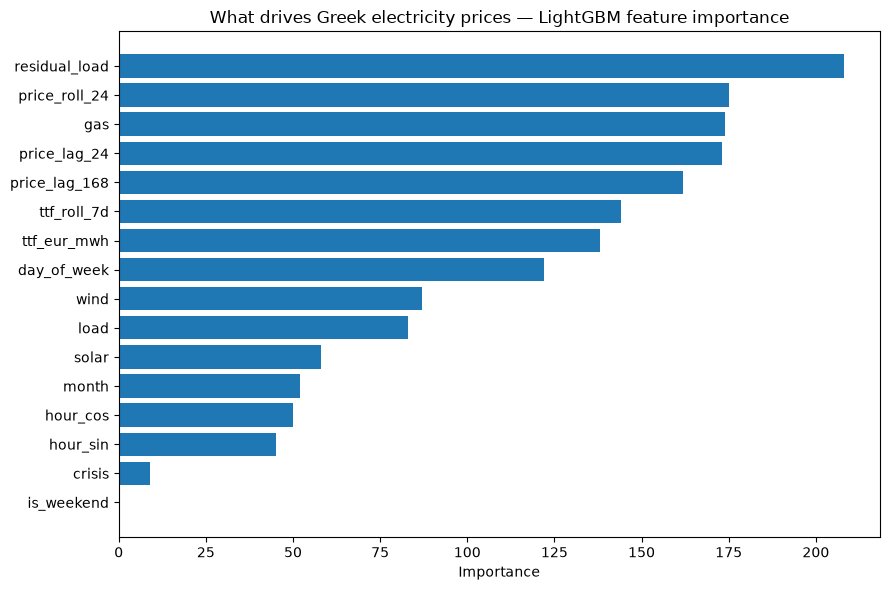

      feature  importance
residual_load         208
price_roll_24         175
          gas         174
 price_lag_24         173
price_lag_168         162
  ttf_roll_7d         144
  ttf_eur_mwh         138
  day_of_week         122
         wind          87
         load          83
        solar          58
        month          52
     hour_cos          50
     hour_sin          45
       crisis           9
   is_weekend           0


In [24]:
imp = pd.DataFrame({
    "feature": FEATURES,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp["feature"][::-1], imp["importance"][::-1])
ax.set_xlabel("Importance")
ax.set_title("What drives Greek electricity prices — LightGBM feature importance")
plt.tight_layout()
plt.savefig("../plots/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(imp.to_string(index=False))

In [25]:
imp_gain = pd.DataFrame({
    "feature": FEATURES,
    "gain": lgb_model.booster_.feature_importance(importance_type="gain")
}).sort_values("gain", ascending=False)
print(imp_gain.to_string(index=False))

      feature         gain
 price_lag_24 9.174647e+08
price_lag_168 1.081272e+08
price_roll_24 8.047832e+07
residual_load 4.644715e+07
  ttf_eur_mwh 4.252095e+07
          gas 3.078942e+07
  ttf_roll_7d 2.137756e+07
  day_of_week 1.229799e+07
         wind 8.655288e+06
         load 8.509317e+06
        month 4.387662e+06
        solar 3.255611e+06
     hour_sin 3.137278e+06
     hour_cos 2.712716e+06
       crisis 5.101901e+05
   is_weekend 0.000000e+00


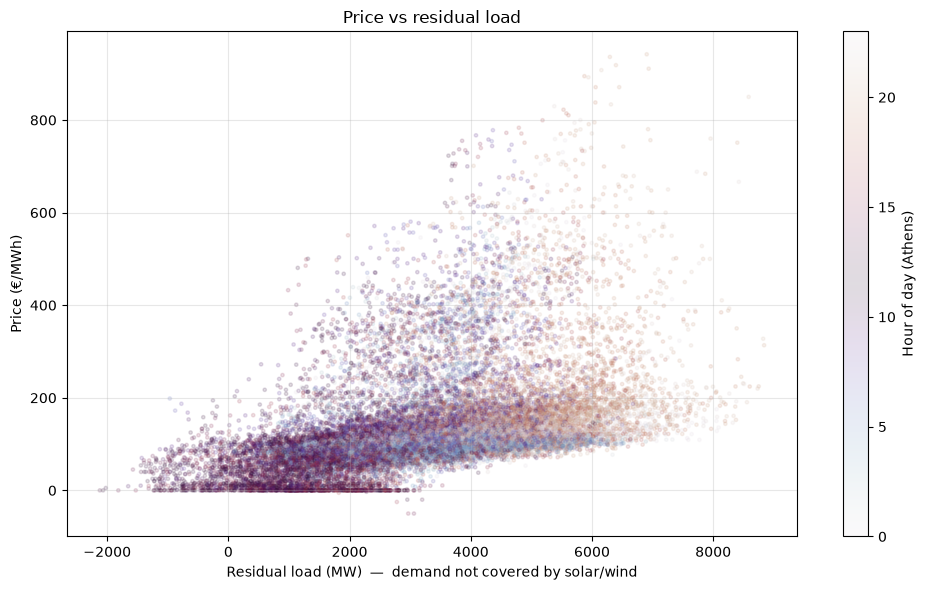

In [26]:
plt.close("all")
d = model_df.dropna(subset=["residual_load", "price"])

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(d["residual_load"], d["price"], alpha=0.15, s=6,
                c=d["hour"], cmap="twilight")
ax.set_xlabel("Residual load (MW)  —  demand not covered by solar/wind")
ax.set_ylabel("Price (€/MWh)")
ax.set_title("Price vs residual load")
plt.colorbar(sc, ax=ax, label="Hour of day (Athens)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/price_vs_residual_load.png", dpi=150, bbox_inches="tight")
plt.show()

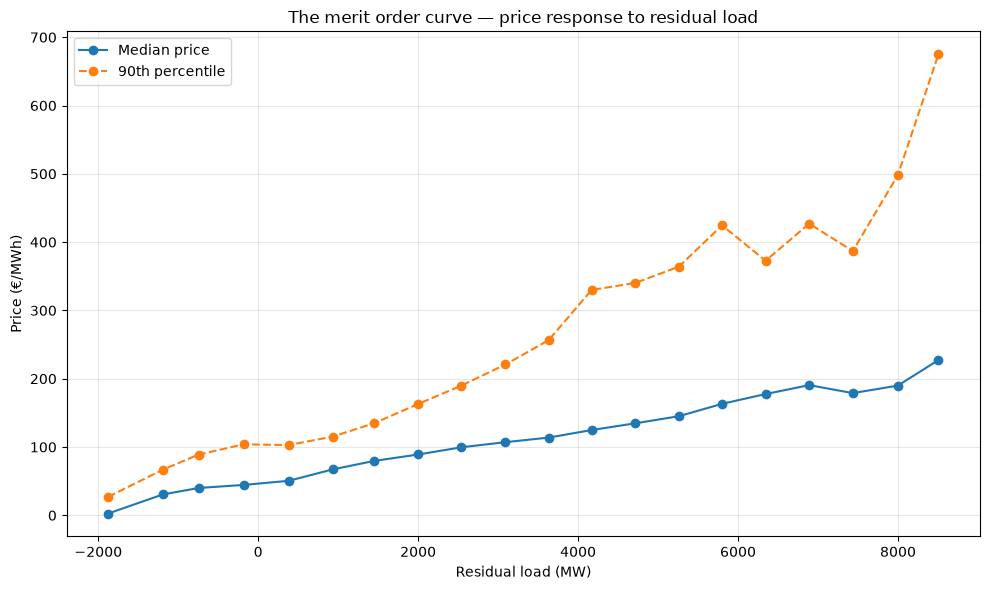

In [27]:
d["rl_bin"] = pd.cut(d["residual_load"], bins=20)
binned = d.groupby("rl_bin", observed=True).agg(
    rl=("residual_load", "mean"),
    price_med=("price", "median"),
    price_p90=("price", lambda x: x.quantile(0.90))
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(binned["rl"], binned["price_med"], marker="o", label="Median price")
ax.plot(binned["rl"], binned["price_p90"], marker="o", linestyle="--", label="90th percentile")
ax.set_xlabel("Residual load (MW)")
ax.set_ylabel("Price (€/MWh)")
ax.set_title("The merit order curve — price response to residual load")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/merit_order_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
model_df.to_csv("C:/Users/lalib/AppData/Local/Programs/data/model_dataset.csv", index=False)
print("Saved:", len(model_df), "rows,", len(model_df.columns), "columns")
print(model_df.columns.tolist())

Saved: 26120 rows, 29 columns
['datetime', 'price', 'load', 'solar', 'wind', 'gas', 'lignite', 'hydro', 'net_import_bg', 'net_import_it', 'net_import_mk', 'hour', 'day_of_week', 'month', 'date', 'ttf_eur_mwh', 'local', 'year', 'is_weekend', 'season', 'residual_load', 'price_lag_24', 'price_lag_168', 'load_lag_24', 'price_roll_24', 'ttf_roll_7d', 'hour_sin', 'hour_cos', 'crisis']
